# BBC News Text Classification using LSTM
This notebook trains an LSTM model to classify news articles into 5 categories:
- business
- tech
- entertainment
- sports
- politics

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

## 2. Load the Dataset

In [5]:
train_df = pd.read_csv('//content//drive//MyDrive//ML_Files//Lab9//BBC News Train.csv')
test_df = pd.read_csv('//content//drive//MyDrive//ML_Files//Lab9//BBC News Test.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print("\nFirst few rows of training data:")
print(train_df.head())

Training data shape: (1490, 3)
Test data shape: (735, 2)

First few rows of training data:
   ArticleId                                               Text  Category
0       1833  worldcom ex-boss launches defence lawyers defe...  business
1        154  german business confidence slides german busin...  business
2       1101  bbc poll indicates economic gloom citizens in ...  business
3       1976  lifestyle  governs mobile choice  faster  bett...      tech
4        917  enron bosses in $168m payout eighteen former e...  business


## 3. Data Exploration

In [6]:
print("\nColumn names:")
print(train_df.columns.tolist())

print("\nDataset Info:")
print(train_df.info())

print("\nMissing values:")
print(train_df.isnull().sum())

print("\nCategory distribution in training data:")
print(train_df['Category'].value_counts())


Column names:
['ArticleId', 'Text', 'Category']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB
None

Missing values:
ArticleId    0
Text         0
Category     0
dtype: int64

Category distribution in training data:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


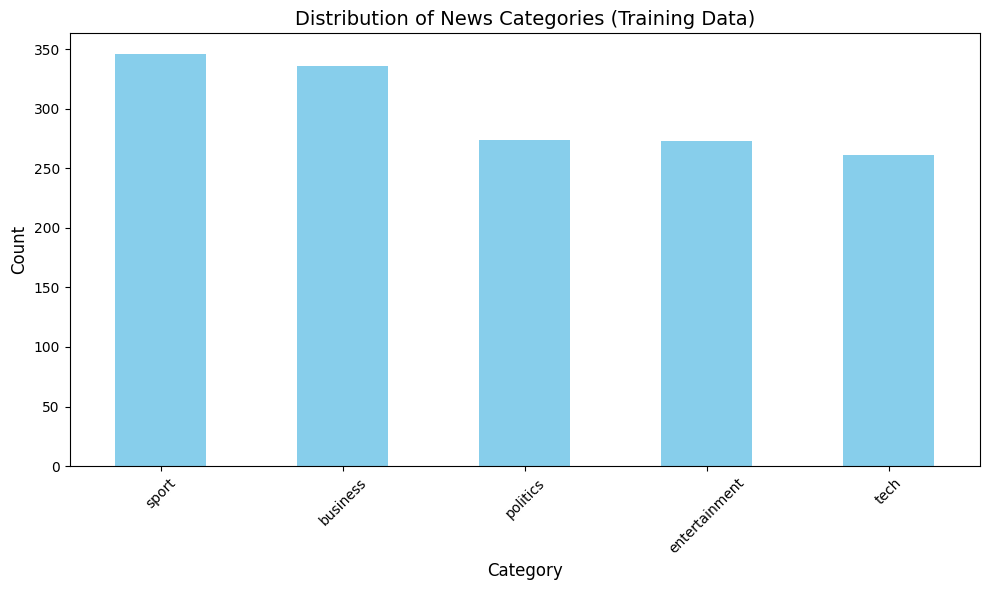

In [7]:
plt.figure(figsize=(10, 6))
train_df['Category'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of News Categories (Training Data)', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Text Preprocessing

In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

train_df['Text'] = train_df['Text'].astype(str).apply(clean_text)
test_df['Text'] = test_df['Text'].astype(str).apply(clean_text)

print("Sample cleaned text:")
print(train_df['Text'].iloc[0][:200])

Sample cleaned text:
worldcom exboss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness cynthia cooper worl


## 5. Prepare Labels

In [12]:
categories = ['business', 'tech', 'entertainment', 'sport', 'politics'] # Corrected 'sports' to 'sport'
category_to_id = {cat: idx for idx, cat in enumerate(categories)}
id_to_category = {idx: cat for cat, idx in category_to_id.items()}

train_df['CategoryID'] = train_df['Category'].map(category_to_id)
# test_df['CategoryID'] = test_df['Category'].map(category_to_id) # Removed this line

print("Category mapping:")
print(category_to_id)

Category mapping:
{'business': 0, 'tech': 1, 'entertainment': 2, 'sport': 3, 'politics': 4}


## 6. Tokenization and Padding

In [15]:
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['Text'])

X_train = tokenizer.texts_to_sequences(train_df['Text'])
X_test = tokenizer.texts_to_sequences(test_df['Text'])

X_train = pad_sequences(X_train, maxlen=max_len, padding='post', truncating='post')
X_test = pad_sequences(X_test, maxlen=max_len, padding='post', truncating='post')

y_train = keras.utils.to_categorical(train_df['CategoryID'], num_classes=5)
# y_test = keras.utils.to_categorical(test_df['CategoryID'], num_classes=5) # Commented out as test_df does not have 'CategoryID'

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
# print(f"y_test shape: {y_test.shape}") # Commented out as y_test is not created
print(f"\nVocabulary size: {len(tokenizer.word_index) + 1}")

KeyError: 'CategoryID'

## 7. Text Length Analysis

In [ ]:
train_df['text_length'] = train_df['Text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train_df['text_length'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Text Length', fontsize=12)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(max_len, color='red', linestyle='--', label=f'Max Length ({max_len})')
plt.legend()

plt.subplot(1, 2, 2)
train_df.groupby('Category')['text_length'].mean().plot(kind='bar', color='coral')
plt.title('Average Text Length by Category', fontsize=12)
plt.xlabel('Category')
plt.ylabel('Average Word Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(f"\nText length statistics:")
print(train_df['text_length'].describe())

## 8. Build LSTM Model

In [ ]:
embedding_dim = 128

model = keras.Sequential([
    layers.Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    layers.SpatialDropout1D(0.2),

    layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
    layers.Bidirectional(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2)),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

model.summary()

## 9. Compile the Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 10. Train the Model

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

## 11. Evaluate the Model

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

## 12. Plot Training History

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Make Predictions

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true_classes, y_pred_classes)
print(f"\nTest Set Accuracy: {accuracy:.4f}")

## 14. Confusion Matrix

In [ ]:
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

## 15. Classification Report

In [ ]:
print("\nClassification Report:")
print("=" * 60)
print(classification_report(y_true_classes, y_pred_classes, target_names=categories))

## 16. Sample Predictions

In [ ]:
sample_indices = np.random.choice(len(X_test), 10, replace=False)

print("\nSample Predictions:")
print("=" * 80)

for idx in sample_indices:
    true_label = id_to_category[y_true_classes[idx]]
    pred_label = id_to_category[y_pred_classes[idx]]
    confidence = np.max(y_pred[idx]) * 100

    print(f"\nText: {test_df.iloc[idx]['Text'][:150]}...")
    print(f"True Category: {true_label}")
    print(f"Predicted Category: {pred_label} (Confidence: {confidence:.2f}%)")
    print("-" * 80)

## 17. Prediction Function

In [ ]:
def predict_category(text):
    cleaned_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')
    prediction = model.predict(padded, verbose=0)
    predicted_class = np.argmax(prediction, axis=1)[0]
    confidence = np.max(prediction) * 100
    category = id_to_category[predicted_class]

    print(f"\nInput Text: {text[:200]}...")
    print(f"\nPredicted Category: {category.upper()}")
    print(f"Confidence: {confidence:.2f}%")
    print("\nProbabilities for all categories:")
    for i, cat in enumerate(categories):
        print(f"  {cat}: {prediction[0][i]*100:.2f}%")

    return category, confidence

sample_text = "The stock market showed significant gains today as tech companies reported strong earnings."
predict_category(sample_text)

## 18. Save the Model and Tokenizer

In [ ]:
model.save('bbc_news_lstm_model.h5')
print("Model saved successfully!")

import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved successfully!")

## 19. Per-Category Performance Analysis

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_true_classes, y_pred_classes)

performance_df = pd.DataFrame({
    'Category': categories,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\nPer-Category Performance:")
print(performance_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

performance_df.plot(x='Category', y='Precision', kind='bar', ax=axes[0], color='skyblue', legend=False)
axes[0].set_title('Precision by Category')
axes[0].set_ylabel('Precision')
axes[0].set_ylim([0, 1.1])

performance_df.plot(x='Category', y='Recall', kind='bar', ax=axes[1], color='lightcoral', legend=False)
axes[1].set_title('Recall by Category')
axes[1].set_ylabel('Recall')
axes[1].set_ylim([0, 1.1])

performance_df.plot(x='Category', y='F1-Score', kind='bar', ax=axes[2], color='lightgreen', legend=False)
axes[2].set_title('F1-Score by Category')
axes[2].set_ylabel('F1-Score')
axes[2].set_ylim([0, 1.1])

plt.tight_layout()
plt.show()